## 数据读取与分析


|特征类型|具体特征|物理意义|
|----|----|----|
|形态特征|Area, Perimeter, Aspect_Ratio等8项|反映显微组织的几何特征（如晶粒尺寸、形状均匀性）|
|化学成分|C, Si, Mn, P, S, Ni, Cr, Fe|决定材料相变行为和最终性能的关键元素|
|工艺参数|carburizing_temp, quenching_temp, tempering_temp|控制材料热处理过程中组织转变的核心参数|

科学依据：

- 根据经典的Hall-Petch关系，晶粒尺寸（与Area相关）直接影响硬度
- 碳含量（C）和合金元素（如Cr）通过固溶强化机制影响硬度
- 淬火温度与冷却速度共同决定马氏体转变程度（Ashby材料选择原理）

### 1 数据加载与初步观察   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('merged_dataset.csv')

# 查看基本信息
print("数据维度:", df.shape)
print("\n前3行示例:")
display(df.head(3))

# 检查列名与数据类型
# print("\n数据类型:")
# print(df.dtypes)

数据维度: (147, 29)

前3行示例:


,Area,Perimeter,Aspect_Ratio,Circularity,Compactness,Density,Mean_Spacing,Uniformity,Image_Name,cr_name,...,Fe,Density_y,ElectricalConductivity,ThermalConductivity,BulkModulus,YoungsModulus,SpecificHeatCapacity,carburizing_temp,quenching_temp,tempering_temp
0,54123.450000,11797.289387,1.025628,0.008933,214.086053,0.832565,135.918415,0.496212,114.png,4Cr,...,84.11,7.66,0.000002,17.52,169.5,216.06,0.46,1050,1020,200
1,57853.700000,9757.700043,1.013061,0.008601,135.917365,0.883130,132.513203,0.493412,113.png,4Cr,...,84.11,7.66,0.000002,17.52,169.5,216.06,0.46,1050,1020,200
2,53632.085714,12566.102891,1.016320,0.004573,240.703142,0.819112,138.251797,0.491054,117.png,4Cr,...,84.11,7.66,0.000002,17.52,169.5,216.06,0.46,1050,1020,200


### 2 缺失值检测

In [2]:
missing = df.isnull().sum()
print("缺失值统计:")
print(missing[missing > 0])

缺失值统计:
Series([], dtype: int64)


### 3 目标变量(hv_data)结构分析

In [3]:
# 转换字符串为数组
df['hv_data'] = df['hv_data'].apply(eval)

# 分析测量点数量分布
points_count = df['hv_data'].apply(len)
# print("\n硬度测量点数统计:")
# print(points_count.describe())

# ====================
# 数据预处理增强
# ====================
# 提取硬度统计特征（需先确保hv_data已转换为数组）
df['hv_mean'] = df['hv_data'].apply(np.mean)
df['hv_std'] = df['hv_data'].apply(np.std)
df['hv_max'] = df['hv_data'].apply(np.max)

# 绘制典型曲线示例
# plt.figure(figsize=(12,6))
# for i in np.random.choice(df.index, 15):  # 随机选3个样本
#     plt.plot(df['hv_data'][i], label=f'Sample {i}')
# plt.xlabel('Measurement Position')
# plt.ylabel('Hardness (HV)')
# plt.title('Hardness Show')
# plt.legend()
# plt.show()

In [4]:
# 验证材料成分总和
element_cols = ['C', 'Si', 'Mn', 'P', 'S', 'Ni', 'Cr', 'Fe']
df['element_sum'] = df[element_cols].sum(axis=1)

## 特征分布分析 

### 1 ✨ 数值特征分布

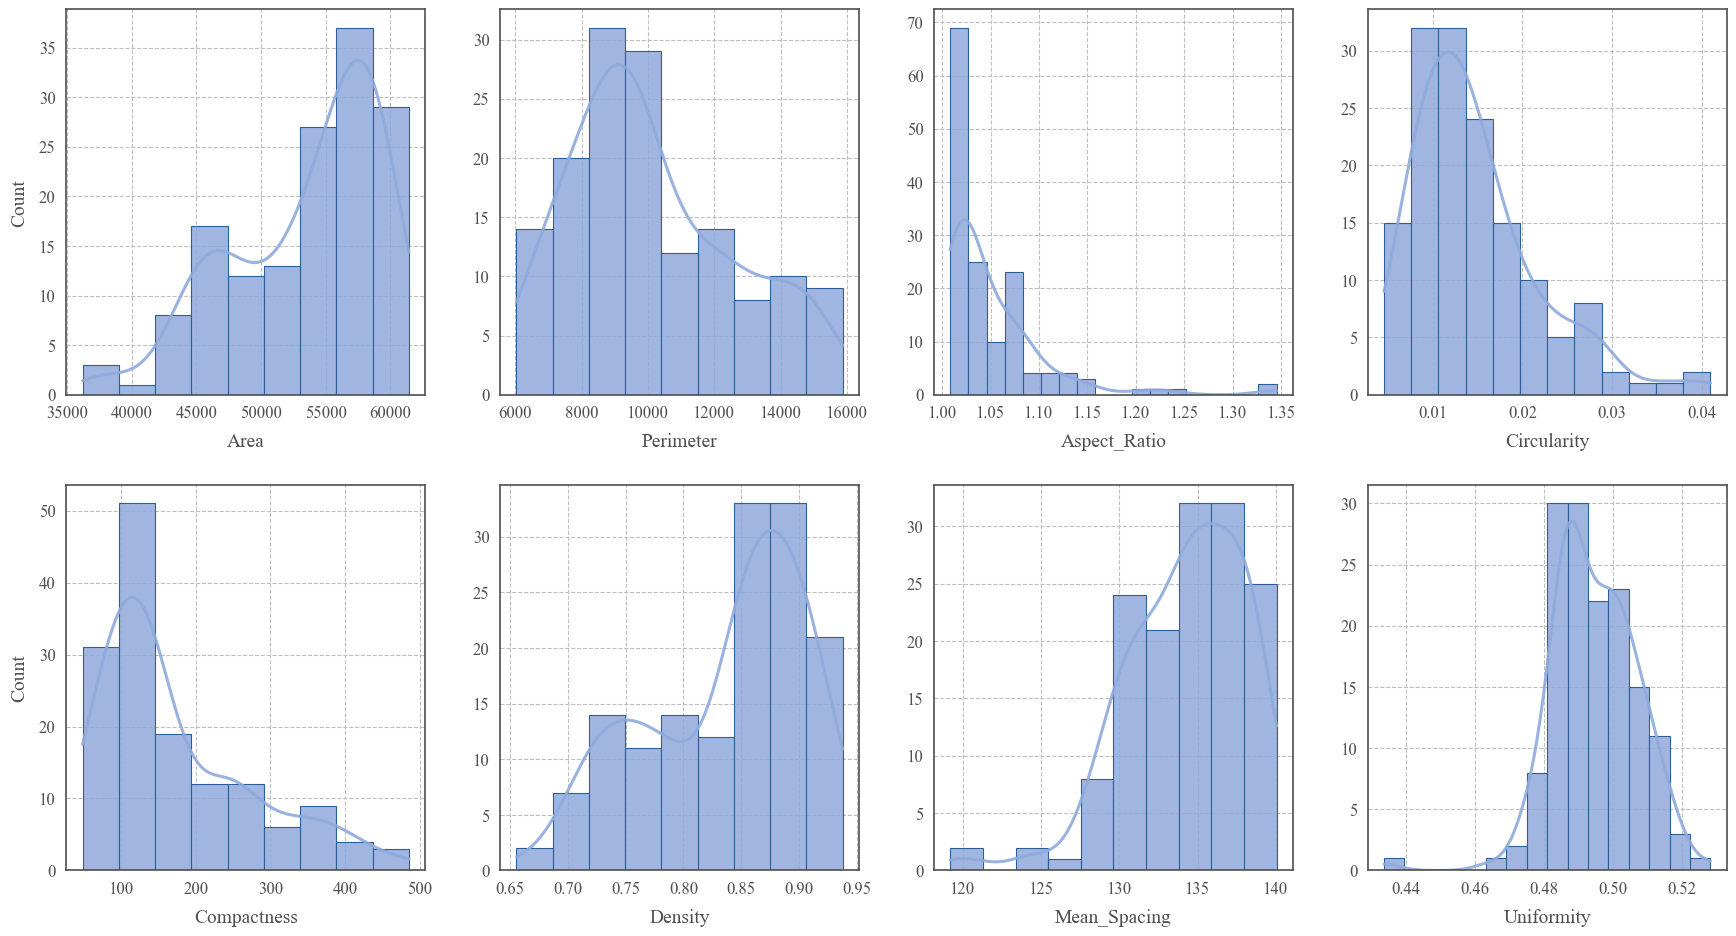

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 颜色配置字典
# =====================
color_config = {
    "hist_fill": "#8FAADC",
    "hist_edge": "#2B5F97",
    "kde_line": "#2e2dff",
    "axis_color": "#4F4F4F",
    "grid_color": "#BFBFBF",
    "bg_color": "#FFFFFF"
}

# =====================
# 全局样式设置
# =====================
sns.set_style("whitegrid", {"grid.linestyle": "--"})
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.edgecolor": color_config["axis_color"],
    "axes.linewidth": 1.2,
    "grid.color": color_config["grid_color"],
    "figure.facecolor": color_config["bg_color"],
    "axes.facecolor": color_config["bg_color"]
})

# =====================
# 特征分布分析
# =====================
plt.figure(figsize=(18, 10), dpi=100, facecolor=color_config["bg_color"])

num_features = ["Area", "Perimeter", "Aspect_Ratio", "Circularity",
                "Compactness", "Density", "Mean_Spacing", "Uniformity"]

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 4, i)
    ax = sns.histplot(
        df[col],
        kde=True,
        color=color_config["hist_fill"],
        edgecolor=color_config["hist_edge"],
        linewidth=0.8,
        alpha=0.85,
        # 关键修复：通过 line_kws 设置 KDE 曲线
        line_kws={
            "color": color_config["kde_line"],
            "linewidth": 2.2,
            "alpha": 0.9
        }
    )
    
    # 标题和标签设置
    plt.title("")
    plt.xlabel(col, fontsize=14, labelpad=8,
              color=color_config["axis_color"],
              fontname='Times New Roman')
    plt.ylabel('Count' if i % 4 == 1 else '',
              fontsize=14, labelpad=8,
              color=color_config["axis_color"],
              fontname='Times New Roman')
    
    # 刻度标签设置
    ax.tick_params(colors=color_config["axis_color"], length=4, width=1.2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties("Times New Roman")
        label.set_size(12)

plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=2.5)
plt.show()

### 2 材料成分总和分布

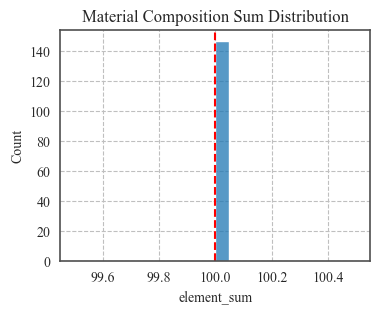

In [6]:
# 2. 材料成分总和分布
plt.figure(figsize=(4,3))
sns.histplot(df['element_sum'], bins=20)
plt.axvline(100, color='red', linestyle='--')
plt.title('Material Composition Sum Distribution')
plt.show()

### 3 工艺参数箱线图

### 4 类别特征分布

物理意义： 
1. cr_name和process_num作为类别特征，表征 离散的生产要素组合
2. 分布形态反映生产计划中的 工艺偏好 或 数据采集偏差  

分析目的： 
1. 识别 类别不平衡风险（如process_num=5的样本占比90%，可能导致模型忽略其他工艺）
2. 发现 潜在的生产模式（例如4Cr只采用特定工艺编号） 
3. 为 分层抽样 或 样本加权 提供依据

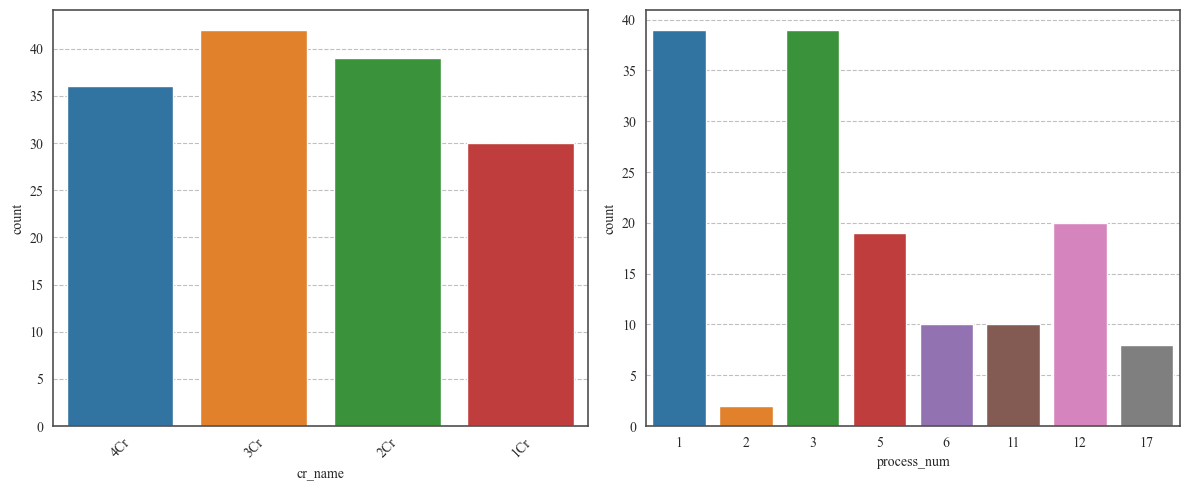

In [8]:

fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x='cr_name', ax=ax[0])
ax[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='process_num', ax=ax[1])
plt.tight_layout()
plt.show()

## 相关性分析
### 1 ✨ 特征-目标相关性

物理意义： 
1. 量化各因素对硬度的 线性影响强度（如碳含量每增加0.1%，硬度提升多少HV） 
2. 符合冶金学中的 Hall-Petch关系（晶粒度影响硬度）等基本原理  

分析目的： 
1. 筛选 关键控制参数（如发现quenching_temp相关系数达-0.6，说明淬火温度是主要调控手段） 
2. 验证 数据逻辑合理性（例如Cr含量应与硬度正相关，若实际相关系数为负需检查数据错误） 
3. 指导 特征工程优先级（强相关特征优先保留，弱相关特征可考虑删除）

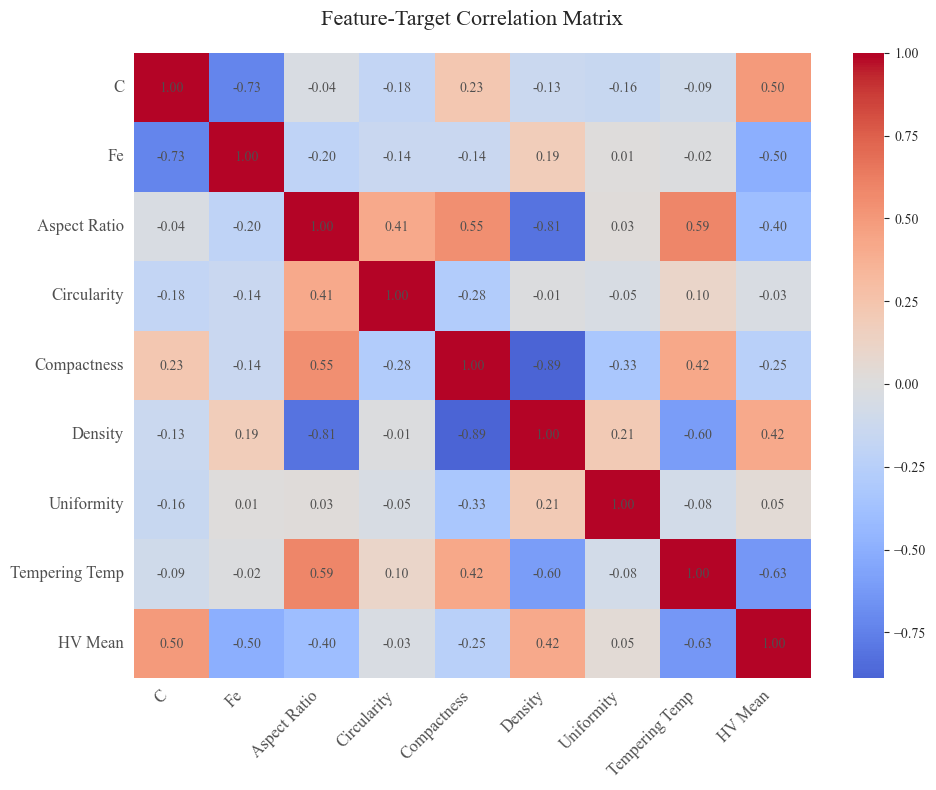

In [9]:
# =====================
# 相关性分析
# =====================

# =====================
# 标签配置字典 (在此编辑显示名称)
# =====================
label_config = {
    # 原始列名: 显示名称
    "C": "C",
    "Fe": "Fe",
    "Aspect_Ratio": "Aspect Ratio",
    "Circularity": "Circularity",
    "Compactness": "Compactness", 
    "Density": "Density",
    "Uniformity": "Uniformity",
    "tempering_temp": "Tempering Temp",
    "hv_mean": "HV Mean"
}

# =====================
# 数据准备
# =====================
target = 'hv_mean'
features = ["C","Fe", "Aspect_Ratio","Circularity","Compactness", "Density","Uniformity","tempering_temp"]
# 纵横比、圆度、紧密度、密度、均匀度、回火温度
# 生成显示标签列表
feature_labels = [label_config.get(col, col) for col in features]
target_label = label_config.get(target, target)

# =====================
# 绘制相关性热力图
# =====================
plt.figure(figsize=(10, 8), facecolor=color_config["bg_color"])

# 计算相关性矩阵
correlations = df[features + [target]].corr(method='spearman')

# 绘制热力图
ax = sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",  # 显示两位小数
    cmap='coolwarm',
    center=0,
    annot_kws={
        "fontsize": 10,
        "fontfamily": "Times New Roman",
        "color": color_config["axis_color"]
    },
    xticklabels=feature_labels + [target_label],  # 自定义x轴标签
    yticklabels=feature_labels + [target_label]   # 自定义y轴标签
)

# 样式调整
ax.tick_params(
    axis='both',
    which='both',
    labelsize=12,
    colors=color_config["axis_color"],
    rotation=45
)

plt.title(
    'Feature-Target Correlation Matrix',
    fontsize=16,
    pad=20,
    fontfamily='Times New Roman'
)

plt.xticks(rotation=45, ha='right')  # x标签倾斜45度
plt.yticks(rotation=0)  # y标签不旋转

# 设置坐标轴标签样式
ax.set_xlabel('')  # 隐藏默认x轴标签
ax.set_ylabel('')  # 隐藏默认y轴标签

plt.tight_layout()
# plt.show()

In [10]:
# =====================
# 导出Origin用数据
# =====================
# 生成带显示标签的相关系数矩阵
correlations_labeled = correlations.rename(
    index=label_config, 
    columns=label_config
)

# 保存为CSV（兼容Origin矩阵导入）
output_path = "./Spearman_Correlation_Matrix.csv"
correlations_labeled.to_csv(
    output_path,
    index=True,  # 保留行标签
    header=True,  # 保留列标签
    float_format="%.3f",  # 保留3位小数
    encoding='utf-8-sig'  # 支持中文标签
)

# 生成说明文本
print(f"""
数据已导出至：{output_path}
Origin导入步骤：
1. 打开Origin → File → Import → CSV
2. 选择矩阵数据模式 (Matrix)
3. 设置参数：
   - Separator: Comma
   - Numeric Format: Float (%.3f)
4. 使用Plot → Contour/Heatmap → Heatmap绘制
5. 坐标轴标签对应CSV首行/首列
""")


数据已导出至：./Spearman_Correlation_Matrix.csv
Origin导入步骤：
1. 打开Origin → File → Import → CSV
2. 选择矩阵数据模式 (Matrix)
3. 设置参数：
   - Separator: Comma
   - Numeric Format: Float (%.3f)
4. 使用Plot → Contour/Heatmap → Heatmap绘制
5. 坐标轴标签对应CSV首行/首列



In [ ]:
# =====================
# 工艺参数交互分析
# =====================

# =====================
# 标签配置字典 (在此编辑显示名称)
# =====================
label_config = {
    # 坐标标签
    'x_labels': {
        'carburizing_temp': 'Carburizing Temp. (°C)',
        'quenching_temp': 'Quenching Temp. (°C)',
        'tempering_temp': 'Tempering Temp. (°C)'
    },
    'y_label': 'Mean HV',
    # 颜色条标签
    'cbar_label': 'HV',
    # 趋势线标签
    'trendline_label': 'trendline label'
}

# =====================
# 可视化配置参数
# =====================
style_config = {
    'font_size': 16,           # 全局字体大小
    'label_pad': 6,           # 标签间距
    'title_fontsize': 16,      # 标题字体大小
    'cbar_label_pos': (4.0, 0.5),  # 颜色条标签位置 (x,y)
    'scatter_sizes': (30, 200), # 散点尺寸范围
    'reg_color': '#D83B2F',     # 趋势线颜色
    'alpha': 0.8               # 透明度
}

# =====================
# 创建带自定义样式的图表
# =====================
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'axes.labelcolor': color_config["axis_color"],
    'axes.titlecolor': color_config["axis_color"]
})

# 创建等宽子图布局
fig = plt.figure(figsize=(20, 6), facecolor=color_config["bg_color"])
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.08], wspace=0.25)  # 新增颜色条专用列
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])]
cax = fig.add_subplot(gs[3])  # 颜色条专用区域

palette = 'viridis'
size_norm = plt.Normalize(df['hv_mean'].min(), df['hv_mean'].max())

for i, feature in enumerate(['carburizing_temp', 'quenching_temp', 'tempering_temp']):
    # 绘制散点图
    sc = sns.scatterplot(
        data=df,
        x=feature,
        y='hv_max',
        hue='hv_mean',
        size='hv_mean',
        palette=palette,
        sizes=style_config['scatter_sizes'],
        alpha=style_config['alpha'],
        ax=axes[i],
        legend=False  # 统一使用右侧颜色条
    )
    
    # 添加趋势线
    sns.regplot(
        data=df,
        x=feature,
        y='hv_max',
        scatter=False,
        color=style_config['reg_color'],
        line_kws={'alpha':0.6, 'label': label_config['trendline_label']},
        ax=axes[i]
    )
    
    # 设置标签和标题
    axes[i].set_xlabel(
        label_config['x_labels'][feature],
        fontsize=style_config['font_size'],
        labelpad=style_config['label_pad']
    )
    axes[i].set_ylabel(
        label_config['y_label'] if i == 0 else '',
        fontsize=style_config['font_size'],
        labelpad=style_config['label_pad']
    )
    axes[i].set_title(
        f"{label_config['x_labels'][feature]} vs Hardness",
        fontsize=style_config['title_fontsize'],
        pad=15
    )
    
    # 设置刻度样式
    axes[i].tick_params(colors=color_config["axis_color"], length=4, width=1.2)
    axes[i].xaxis.set_major_formatter(plt.FormatStrFormatter('%d°C'))

# =====================
# 添加统一颜色条（关键修改部分）
# =====================
sm = plt.cm.ScalarMappable(cmap=palette, norm=size_norm)
sm.set_array([])

# 创建颜色条并绑定到专用区域
cbar = fig.colorbar(
    sm,
    cax=cax,  # 使用预定义的颜色条区域
    orientation='vertical',
    aspect=25
)

# 设置颜色条标签
cbar.set_label(
    label_config['cbar_label'],
    fontsize=style_config['font_size'],
    labelpad=style_config['label_pad'],
    rotation=0,
    y=0.5,
    x=1  # 向右偏移标签位置
)

# 调整刻度标签样式
cbar.ax.tick_params(
    labelsize=style_config['font_size']-1,
    color=color_config["axis_color"],
    direction='out',
    length=4,
    width=1.2
)

# =====================
# 添加趋势线图例（调整位置）
# =====================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    labels,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.85),  # 新位置
    frameon=False,
    fontsize=style_config['font_size']
)

plt.tight_layout()
plt.show()

## 特征工程预判

### 1 共线性检查

In [ ]:
# 1. 特征转换示例
df['log_Area'] = np.log1p(df['Area'])  # 处理右偏分布

# 2. 构造工艺梯度特征
df['temp_gradient'] = df['carburizing_temp'] - df['quenching_temp']

# 3. 合金当量计算（示例公式）
df['carbon_equivalent'] = df['C'] + df['Mn']/6 + df['Cr']/5

# 4. 共线性检查
high_corr_features = ['Circularity', 'Compactness', 'Density']
plt.figure(figsize=(4,3))
sns.heatmap(df[high_corr_features].corr(), annot=True, cmap='coolwarm')
plt.title('Potential Multicollinearity Check')
plt.show()

### 2 ✨ 特征重要性分析


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 特征选择
features1 = ["C","Si","Mn","P","Cr","Fe"]
features2 = ["Area","Perimeter","Aspect_Ratio","Circularity","Compactness","Density","Mean_Spacing","Uniformity"]
features3 = ['carburizing_temp', 'quenching_temp', 'tempering_temp']

X = df[["C","Si","Mn","P","Cr"] + 
       ["Perimeter","Aspect_Ratio","Compactness","Density","Uniformity"] + 
       ['carburizing_temp', 'temp_gradient']]

# X = df[features1 + features2 + features3 + ['carburizing_temp', 'temp_gradient']]
y = df[target]

# 模型训练
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# 获取重要性数据
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 方式1：可视化带数值标注 ----------------------
# =====================
# 可视化配置参数（新增部分）
# =====================
label_config = {
    'x_label': 'Feature importance score',  # 可自定义横坐标名称
    'y_label': 'Feature parameter',       # 可自定义纵坐标名称
    'x_fontsize': 16,           # 横坐标字体大小
    'y_fontsize': 16,           # 纵坐标名称字体大小
    'y_tick_fontsize': 14       # 纵坐标刻度字体大小
}

# =====================
# 可视化带数值标注（修改部分）
# =====================
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=importance, x='importance', y='feature', palette='viridis')

# 添加数值标签
for i in ax.containers[0]:
    width = i.get_width()
    plt.text(width + 0.005, 
             i.get_y() + i.get_height()/2,
             f'{width:.3f}',
             fontsize=label_config['y_tick_fontsize'],  # 使用配置参数
             ha='left', va='center')

# 设置坐标轴标签
plt.title('Importance analysis of processing parameters', fontsize=16)
plt.xlabel(
    label_config['x_label'],
    fontsize=label_config['x_fontsize'],
    labelpad=10  # 新增标签与坐标轴的间距
)
plt.ylabel(
    label_config['y_label'],
    fontsize=label_config['x_fontsize'],
    labelpad=15
)

# 设置纵坐标刻度字体（新增）
ax.tick_params(
    axis='y',
    labelsize=label_config['y_tick_fontsize']
)

plt.xlim(0, importance['importance'].max()*1.2)
plt.tight_layout()
plt.show()


## 数据整理 & 输出

In [ ]:
import pandas as pd
from ast import literal_eval

# 读取原始数据并转换硬度数据格式
df = pd.read_csv('merged_dataset.csv', converters={'hv_data': literal_eval})

# ====================
# 关键步骤1：计算温度梯度
# ====================
# 创建新的温度梯度特征
df['temp_gradient'] = df['carburizing_temp'] - df['quenching_temp']

# ====================
# 关键步骤2：特征选择
# ====================
required_features = [
    "Image_Name",
    "C", "Si", "Mn", "P", "Cr",
    "Perimeter", "Aspect_Ratio", "Compactness",
    "Density", "Uniformity",
    "carburizing_temp", "temp_gradient"  # 包含原始温度和新计算梯度
]

target_column = "hv_data"

# ====================
# 关键步骤3：数据验证
# ====================
# 检查特征是否存在
missing_features = set(required_features) - set(df.columns)
if missing_features:
    raise KeyError(f"缺失必要特征: {missing_features}")

# 验证温度梯度计算
sample_check = df.iloc[0]
assert sample_check['temp_gradient'] == (sample_check['carburizing_temp'] - sample_check['quenching_temp']), "温度梯度计算错误"

# ====================
# 关键步骤4：数据清洗
# ====================
# 去除完全重复行
# df = df.drop_duplicates(subset=required_features + [target_column])

# 过滤无效硬度数据
def is_valid_hv(hv_list):
    return (len(hv_list) >= 5) and (min(hv_list) > 0)

valid_mask = df[target_column].apply(is_valid_hv)
df = df[valid_mask].reset_index(drop=True)

# ====================
# 关键步骤5：保存数据集
# ====================
# 创建最终数据集
final_df = df[required_features + [target_column]]

# 保存为新的CSV（保留原始硬度数组格式）
final_df.to_csv('hardness_curve_dataset.csv', index=False)
